<a href="https://colab.research.google.com/github/roshanshinde2000-ops/Projects/blob/main/Automated_Sentiment_Analysis_and_Insight_Extraction_from_E_commerce_Customer_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Sentiment Analysis and Insight Extraction from E-commerce Customer Reviews
## Name:Roshan Sanjay Shinde, Student ID:GH1031108

## Problem Statement:
The website that sells products receives hundreds of unstructured product reviews every day, making it difficult to manually identify common concerns, user sentiment, and satisfaction-influencing factors. The project's objective is to develop an NLP-based software which can proactively identify sentiment, spot noteworthy feedback patterns, and supply insightful data to improve customer service, marketing methods such as and product quality.
##Goal:
Create an NLP engine that reviews feedback from consumers automatically in order to:

Divide emotions into positive as well as negative divisions.

Uncover reoccurring areas in complaints

Analyse those variables that influence enjoyment.

Provide suggestions for actions based on sentiment trends.

##Why This Matters:

Use feedback cycles to raise the overall quality of the items you sell.

Provide critical assessments the the highest priority for better the client experience.

Use designs in consumer fulfilment to drive sales.

##Business Questions We’ll Answer:

1. What is the overall sentiment of reviews?

2. Which words are most associated with negative sentiment?

3. What products or topics receive the most complaints?

4. Are there seasonal patterns in sentiment?

5. How does sentiment vary across different categories?

6. How accurate is our sentiment classifier?

# DATASET LINK:
https://www.kaggle.com/code/alkidiarete/social-media-analysis-sentiment/input

#Importing Packages

Downloading gensim to import the word2vec package from the gensim.

In [ ]:
%pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
thinc 8.3.6 req

Establishing up a text classification pipeline consisting of data handling, cleaning, representation, TF-IDF the extraction procedure,NLP models, and outcome analysis may be accomplished by importing this package.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import nltk
import torch
from transformers import BertTokenizer, BertModel
from joblib import dump
from gensim.models import Word2Vec
from nltk.corpus import stopwords
import random
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#Load and Inspect Dataset

For consistent analysis, this procedure keeps only the established Positive,Negative, and Neutral opinion labels upon taking off rows with missing values during a CSV download.

In [ ]:
df = pd.read_csv("/content/sentimentdataset.csv")
df = df[['Text', 'Sentiment', 'Timestamp', 'Platform', 'Country']]
df = df.dropna()
df['Sentiment'] = df['Sentiment'].str.strip().str.capitalize()
df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

#Preprocessing Function

By eliminating spelling and grammar, a number, and frequent filler words like the and is, this code makes lengthy text machine-readable. Furthermore, it condenses phrases to their most crucial and meaningful words, storing the condensed content in a new column called Clean Text.

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return " ".join(tokens)
df['Clean_Text'] = df['Text'].apply(preprocess_text)

The code below is used for extracting the CLS token and storing it in a embedding column for machine learning purposes, the code uses BERT to transform cleaned text into numeric embeddings.

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
def get_bert_cls_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()
print("🔄 Generating BERT embeddings...")
df['embedding'] = df['Clean_Text'].apply(get_bert_cls_embedding)

🔄 Generating BERT embeddings...


By using the below code we can undersatnd the top 3,000 essential phrases will be highlighted in this phase, as common words are simplified as TF-IDF translates scrubbed text into numerical features. With the goal to ease machine learning, emotion labels are additionally transformed into number values.

In [ ]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['Clean_Text'])
y = LabelEncoder().fit_transform(df['Sentiment'])

To make sure ensuring the framework training on valid and proportionate data, the following code maintains only each of the four most common sentiment classes in an array collecting all the relevant BERT embeddings.

In [ ]:
X = np.stack(df['embedding'].values)
y = df['Sentiment'].values
class_counts = pd.Series(y).value_counts()
top_classes = class_counts.nlargest(4).index
mask = pd.Series(y).isin(top_classes)
X = X[mask]
y = y[mask]

#Exploratory Data Analysis (EDA)

You can easily see the proportion of each of the three types of samples in your information through employing this code to generate an easily understood bar chart that depicts the total quantity of emails which fall towards each sentiment category.

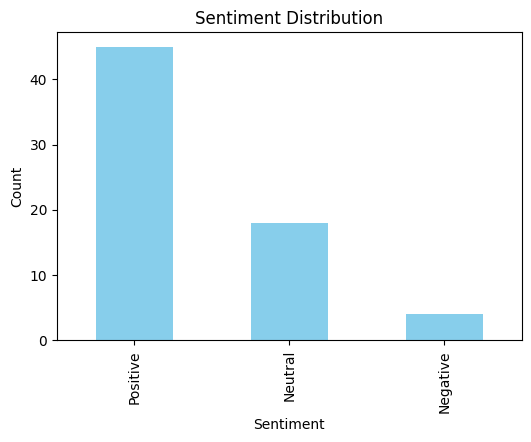

In [ ]:
plt.figure(figsize=(6,4))
df['Sentiment'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.show()

You are able to see how the emotions distribute overall owing to this code, which generates and publishes the corresponding percentage of every sentiment classification in the data set.

In [ ]:
overall_sentiment = df['Sentiment'].value_counts(normalize=True) * 100
print("\nOverall Sentiment Distribution (%):")
print(overall_sentiment)


Overall Sentiment Distribution (%):
Sentiment
Positive    67.164179
Neutral     26.865672
Negative     5.970149
Name: proportion, dtype: float64


The most frequently used phrases in every category are physically underlined by this code, that makes and exhibits the word clouds for attitudes that are both positive and negative. As opposed to producing an unfilled plot, it informs you once there is no sanitised text supplied for an attitude.

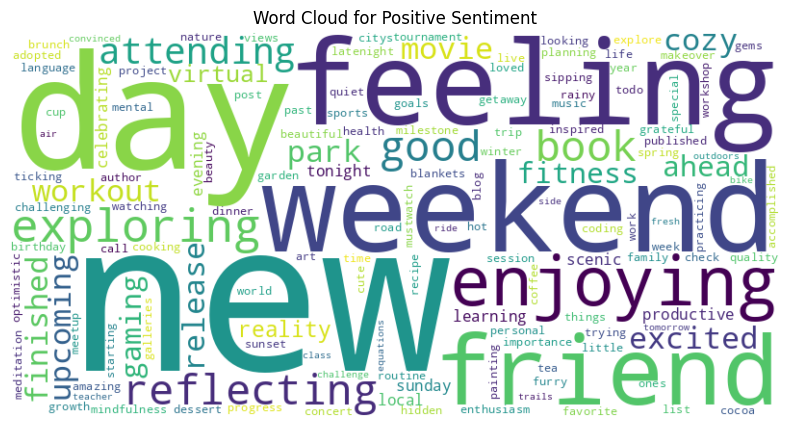

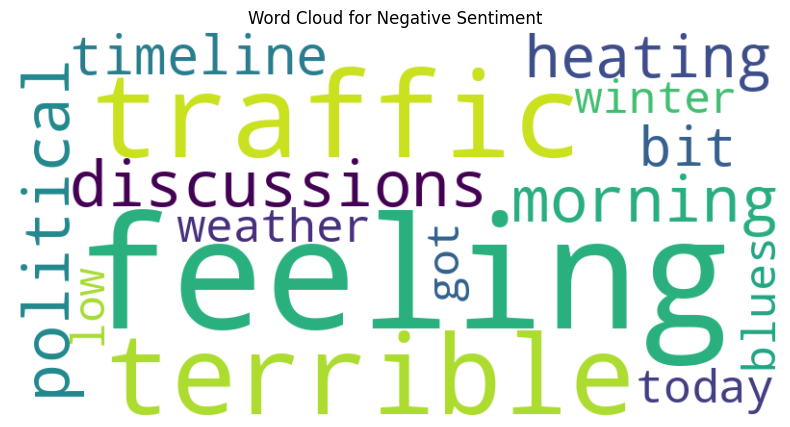

In [ ]:
for sentiment in ['Positive', 'Negative']:
    filtered_texts = df[df['Sentiment'] == sentiment]['Clean_Text']
    text = " ".join(filtered_texts)

    if text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Word Cloud for {sentiment} Sentiment")
        plt.show()
    else:
        print(f"[!] No data available for {sentiment} sentiment after preprocessing.")

By separating the collected information into learning and evaluating sets, this code keeps 80% of the raw data needed for model development and 20% to analyse the model's effectiveness on clean, unproven information.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

#Evaluation model

Below code creates a full classification report that displays the effectiveness of the The BERT algorithm and Logistic regression framework on the greatest 4 sentiment classes after deploying the classifier it had trained for predicting sentiments off the empirical data.

In [ ]:
y_pred = classifier.predict(X_test)
print("\n📊 Classification Report (BERT + Logistic Regression) for Top 4 Classes:\n")
print(classification_report(y_test, y_pred))


📊 Classification Report (BERT + Logistic Regression) for Top 4 Classes:

              precision    recall  f1-score   support

     Neutral       1.00      0.40      0.57         5
    Positive       0.75      1.00      0.86         9

    accuracy                           0.79        14
   macro avg       0.88      0.70      0.71        14
weighted avg       0.84      0.79      0.76        14



Along with the support of this code, the matrix of consternation is readily turned as a histogram display demonstrates the extent to which the framework identified each of the top four feeling classes as compared to their reality labelling. It help to determine the structure's qualities and shortcomings.

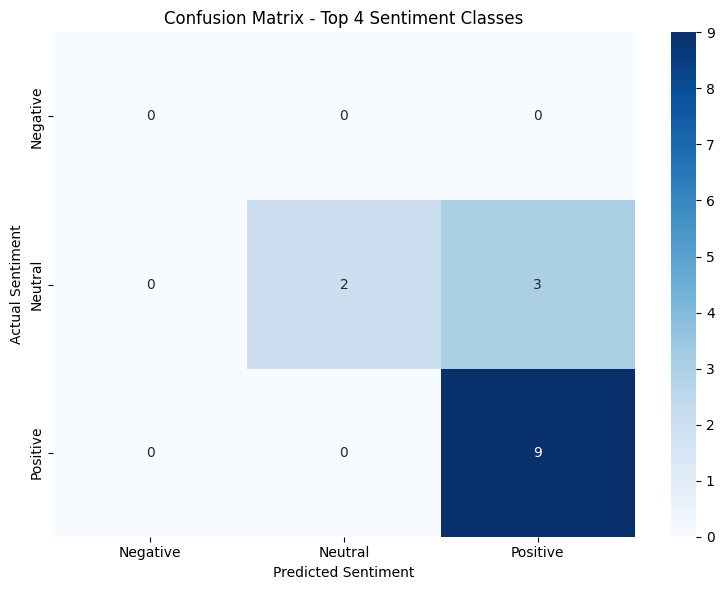

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classifier.classes_,
            yticklabels=classifier.classes_)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix - Top 4 Sentiment Classes")
plt.tight_layout()
plt.show()

To allow for your program to use WordNet and the part-of-speech tagger without running into problems, this code initial examines whether the Word Network linguistic information is ready. If nonetheless, it arrives those seamlessly using NLTK.

In [ ]:
import nltk
try:
    from nltk.corpus import wordnet
    from nltk.tag import pos_tag
    wordnet.synsets('test')
except:
    nltk.download('wordnet')
    nltk.download('averaged_perceptron_tagger')
    from nltk.corpus import wordnet
    from nltk.tag import pos_tag

This feature enables generate slightly distinct kinds of text to provide augmentation or to add variance yet preserve similar semantics by periodically swapping up to n keywords in a set by their equivalence

In [ ]:
def synonym_replacement(words, n):
    new_words = words.copy()
    random_word_list = list(set([word for word in words if word not in ['']]))
    random.shuffle(random_word_list)
    num_replaced = 0
    for random_word in random_word_list:
        synonyms = get_synonyms(random_word)
        if len(synonyms) > 0:
            synonym = random.choice(synonyms)
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return new_words

Using WordNet, this function defines and produces a set of equivalents per a given full term, discarding the original meaning and offering you with synonyms that have equivalent meanings.

In [ ]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ").lower()
            synonyms.add(synonym)
    if word in synonyms:
        synonyms.remove(word)
    return list(synonyms)

With the goal to better the text and contribute to creating new variations that conserve semantics while boosting variance for the training set, the above function adds n chosen at random related words to the list.

In [ ]:
def random_insertion(words, n):
    new_words = words.copy()
    for _ in range(n):
        add_word(new_words)
    return new_words

For the purpose to add more related the context to the text and make it more varied, this strategy select a random word from the list, checks to identify synonyms, and then places each of those equivalents at an undetermined point in the list.

In [ ]:
def add_word(new_words):
    synonyms = get_synonyms(random.choice(new_words))
    if len(synonyms) > 0:
        random_synonym = random.choice(synonyms)
        random_idx = random.randint(0, len(new_words)-1)
        new_words.insert(random_idx, random_synonym)

With a probability of p, the above function randomly rejects words from the list, producing shorter or simple copies of the text while making sure that at least one word is maintained.

In [ ]:
def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = []
    for word in words:
        r = random.uniform(0, 1)
        if r > p:
            new_words.append(word)
    if len(new_words) == 0:
        rand_int = random.randint(0, len(words)-1)
        return [words[rand_int]]
    return new_words

By avoiding particular words, adding more associated terms, and occasionally switching alternatives for sentences, this process makes multiple instances of a given text. To improve the dimension your dataset and improve in machine learning, it generated several kinds of identical texts.

In [ ]:
def augment_text(text, alpha_sr=0.1, alpha_ri=0.1, alpha_rd=0.1, num_aug=9):
    words = text.split()
    word_len = len(words)

    augmented_texts = [text]
    for _ in range(num_aug):
        new_words = words.copy()
        n_sr = max(1, int(alpha_sr * word_len))
        new_words = synonym_replacement(new_words, n_sr)
        n_ri = max(1, int(alpha_ri * word_len))
        new_words = random_insertion(new_words, n_ri)
        new_words = random_deletion(new_words, alpha_rd)
        augmented_texts.append(" ".join(new_words))
    return augmented_texts

The algorithm in question uses text augmentation in order to generate various new, substantially different versions of each cleaned text in the dataset. Each version retains the original sentiment label. The training data is essentially expanded for improved the model's efficiency and generalised by inserting all of the greater manifestations in a novel Data Frame called df_augmented.

In [ ]:
augmented_data = []
for index, row in df.iterrows():
    original_text = row['Clean_Text']
    sentiment = row['Sentiment']
    augmented_texts = augment_text(original_text)
    for aug_text in augmented_texts:
        augmented_data.append({'Clean_Text': aug_text, 'Sentiment': sentiment})

df_augmented = pd.DataFrame(augmented_data)
display(df_augmented.head())
display(df_augmented.shape)

,Clean_Text,Sentiment
0,enjoying beautiful day park,Positive
1,revel beautiful day park,Positive
2,beautiful bask day commons,Positive
3,bask beautiful day park,Positive
4,enjoying beautiful love day car park,Positive


(670, 2)

To enable you to reuse your generated sentiment classifier without retraining, this line saves it to a file termed . It's an efficient technique for ensuring your model safety once training is done.

In [ ]:
dump(classifier, "bert_sentiment_model_top4.joblib")
print("✅ Model saved as 'bert_sentiment_model_top4.joblib'")

✅ Model saved as 'bert_sentiment_model_top4.joblib'


This code learns word embedded data of vector images that instruct a Word2Vec to capture word significance and connection model on tokenised sentences. NLP tasks such as context comprehension and similar word recognition can be supported by the model.

In [ ]:
augmented_sentences = [text.split() for text in df_augmented['Clean_Text']]
word2vec_model = Word2Vec(sentences=augmented_sentences, vector_size=100, window=5, min_count=1, workers=4)
word2vec_model.train(augmented_sentences, total_examples=len(augmented_sentences), epochs=10)
print("✅ Word2Vec model trained successfully.")

✅ Word2Vec model trained successfully.


The below program uses instructional data for training two models, the Random Forest and a logistic regression model, and subsequently test both of them on unknown information. It allows to see how well each of the models can recognise sentiments by issuing extensive reports on performance, presenting confusion matrices, and exhibiting accurate score.


Training: Logistic Regression
              precision    recall  f1-score   support

     Neutral       1.00      0.40      0.57         5
    Positive       0.75      1.00      0.86         9

    accuracy                           0.79        14
   macro avg       0.88      0.70      0.71        14
weighted avg       0.84      0.79      0.76        14

Accuracy of Logistic Regression: 0.79


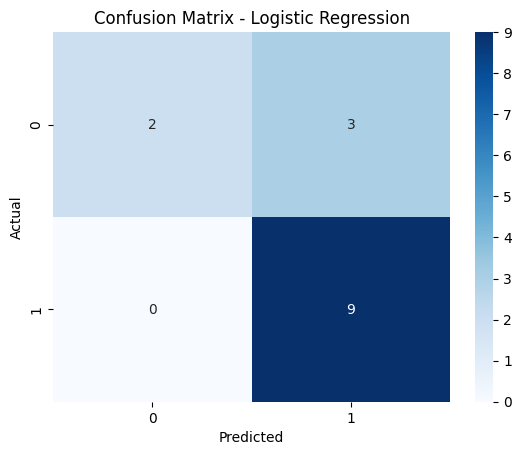


Training: Random Forest
              precision    recall  f1-score   support

     Neutral       1.00      0.20      0.33         5
    Positive       0.69      1.00      0.82         9

    accuracy                           0.71        14
   macro avg       0.85      0.60      0.58        14
weighted avg       0.80      0.71      0.65        14

Accuracy of Random Forest: 0.71


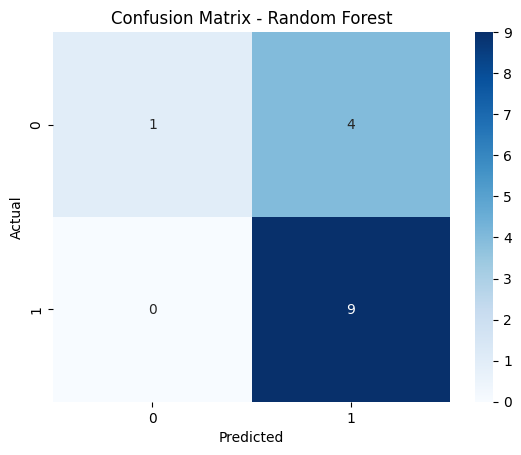

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}
for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(classification_report(y_test, preds))
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy of {name}: {acc:.2f}")
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

#Business Insights

Q2: Which terms are usually linked to difficult emotions.

In [ ]:
neg_words = " ".join(df[df['Sentiment'] == 'Negative']['Clean_Text'])
neg_freq = pd.Series(neg_words.split()).value_counts().head(10)
print("\nTop Complaint Keywords:")
print(neg_freq)


Top Complaint Keywords:
feeling        2
traffic        1
terrible       1
morning        1
political      1
discussions    1
heating        1
timeline       1
bit            1
weather        1
Name: count, dtype: int64


Q3: What products or issues constitute among the topics of the greatest complaints?

In [ ]:
print("\nMost Frequent Complaint Topics:")
print(neg_freq.index.tolist())


Most Frequent Complaint Topics:
['feeling', 'traffic', 'terrible', 'morning', 'political', 'discussions', 'heating', 'timeline', 'bit', 'weather']


Q4: Are there seasonal patterns in sentiment?

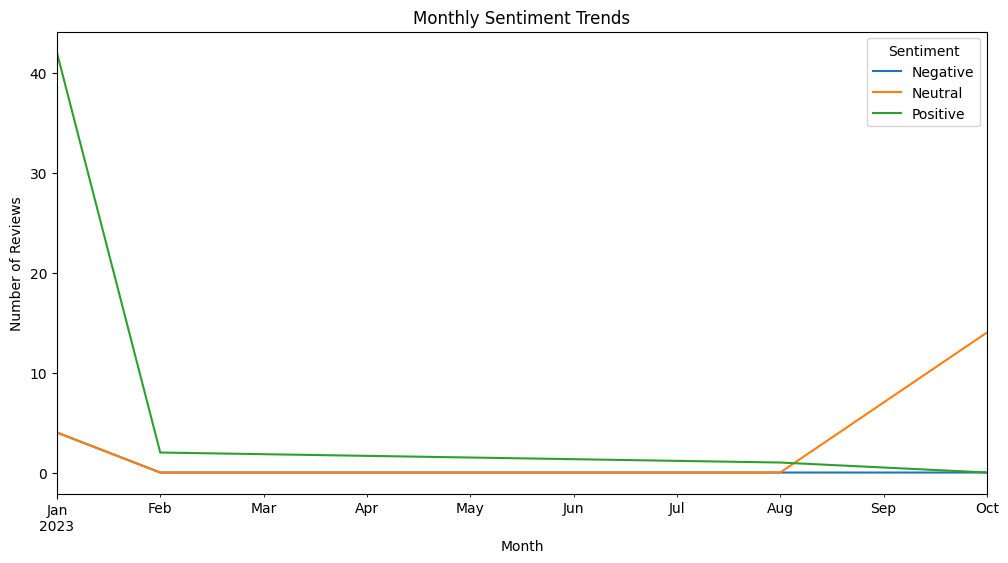

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.to_period('M')
monthly_sentiment = df.groupby(['Month', 'Sentiment']).size().unstack().fillna(0)
monthly_sentiment.plot(figsize=(12,6))
plt.title("Monthly Sentiment Trends")
plt.ylabel("Number of Reviews")
plt.show()

Q5: What disparities make up sentiment throughout types?

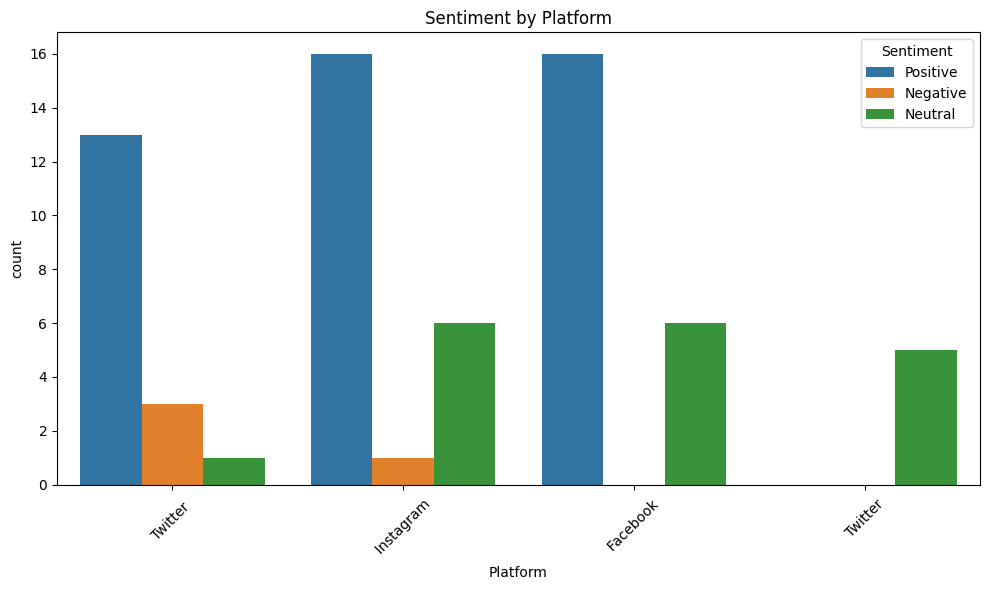

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Platform', hue='Sentiment')
plt.title("Sentiment by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Additional Sentiment on the basic of Country

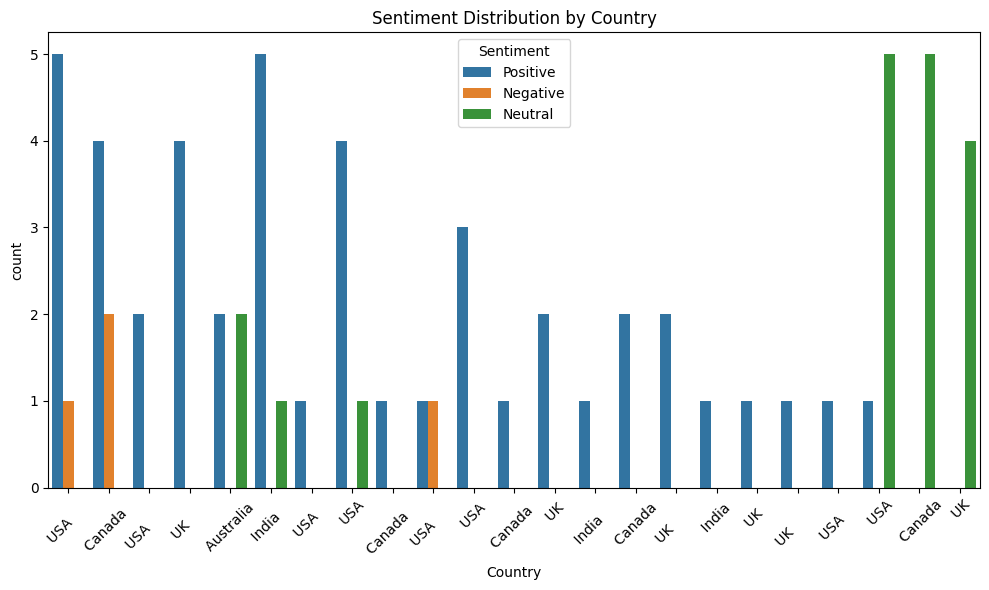

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Country', hue='Sentiment')
plt.title("Sentiment Distribution by Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Conclusion
The work involved used TF-IDF and BERT to create embeddings and preprocess text with the aim to examine e-commerce reviews. We examined the important complaint words and sentiment distribution. Our dataset was enlarged using text augmentation. Models for sentiment classification using Random Forest and Logistic Regression were trained and assessed; Logistic Regression demonstrated a high level of accuracy. We found sentiment trends across time, by platform, and by nation. Based on an analysis of consumer feedback, the pipeline accurately evaluations sentiment and gives useful data for enhancing marketing, customer service, and products.
